Using Colab cache for faster access to the 'global-commodity-trade-statistics' dataset.
Original dataset: (8225871, 10)

Final ML dataset: (5029, 2)
Number of HS Chapters: 96
Minimum examples per chapter: 6

Training samples: 4023
Testing samples: 1006

Training Logistic Regression...

Training Multinomial Naive Bayes...

Training Linear SVM...

BASELINE MODEL COMPARISON
                     Model  Accuracy  Macro F1  Micro F1  Weighted F1
0      Logistic Regression    0.6252    0.4198    0.6252       0.6015
1  Multinomial Naive Bayes    0.4553    0.2081    0.4553       0.4208
2               Linear SVM    0.8101    0.7779    0.8101       0.8035

TUNING LINEAR SVM
Fitting 5 folds for each of 64 candidates, totalling 320 fits

FINAL TUNED SVM RESULTS
Accuracy:      0.8201
Macro F1:      0.7904
Micro F1:      0.8201
Weighted F1:   0.8153

Best Parameters:
{'model__C': 2, 'model__class_weight': None, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}


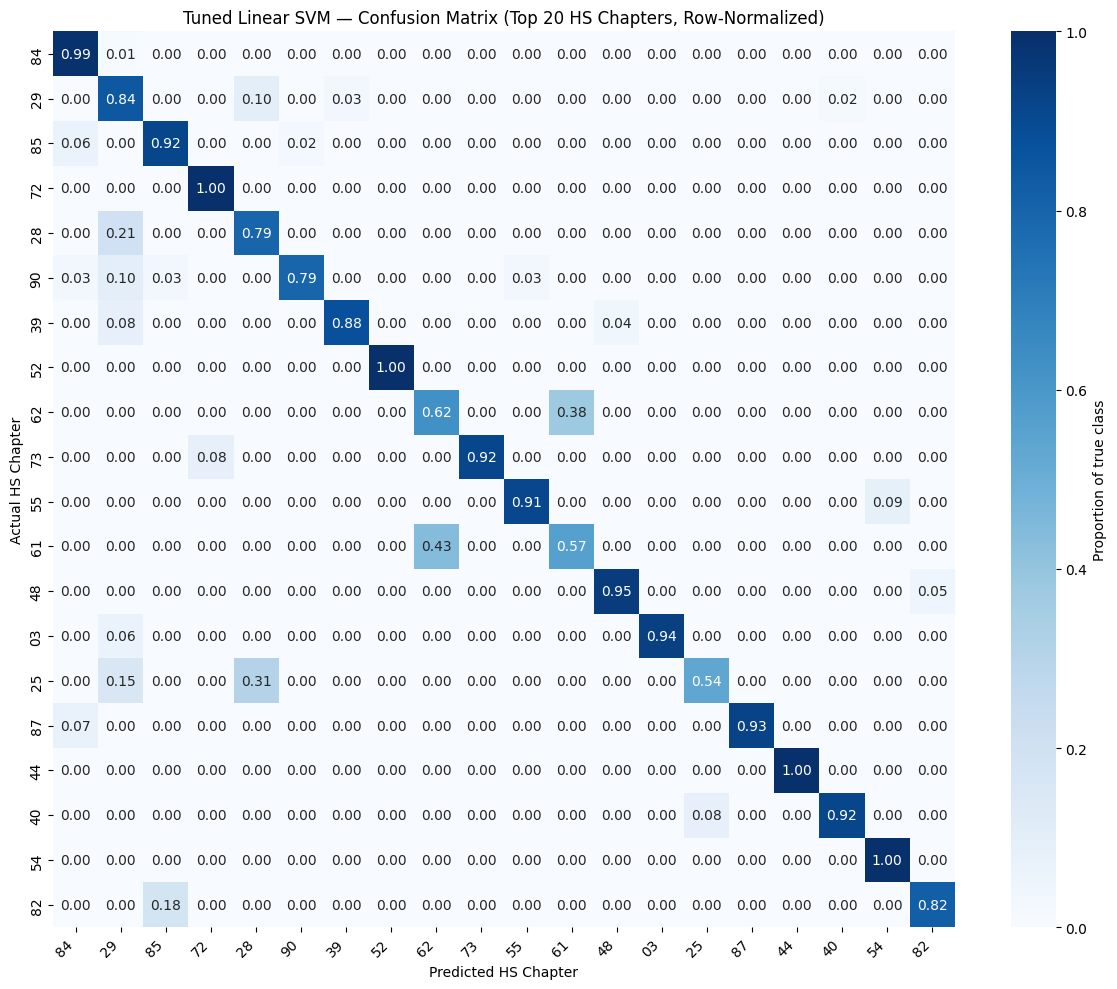


SAMPLE PREDICTIONS
live sheep → HS Chapter 01
live goats → HS Chapter 01
cotton woven fabric → HS Chapter 58
iron or steel products → HS Chapter 73
fresh fish → HS Chapter 08
plastic household articles → HS Chapter 39

FILES SAVED
1. hs_chapter_nlp_classifier.pkl
2. model_comparison_results.csv
3. confusion_matrix.png

PROJECT SUMMARY
Original dataset: (8225871, 10)
Final ML dataset: (5029, 2)
HS Chapters: 96

Final Accuracy: 0.8201
Final Macro F1: 0.7904
Final Weighted F1: 0.8153
Best CV Macro F1: 0.7734


In [1]:
# ============================================================
# HS CHAPTER CLASSIFICATION USING NLP
# Commodity Description → HS Chapter
# ============================================================

import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. LOAD DATA
# ============================================================

path = kagglehub.dataset_download(
    "unitednations/global-commodity-trade-statistics"
)

csv_path = os.path.join(
    path,
    "commodity_trade_statistics_data.csv"
)

df = pd.read_csv(csv_path, low_memory=False)

print("Original dataset:", df.shape)


# ============================================================
# 2. CLEAN DATA
# ============================================================

data = df[["commodity", "comm_code"]].copy()

# Remove aggregate commodity rows and missing values
data = data[
    ~data["commodity"].str.contains(
        "ALL COMMODITIES",
        case=False,
        na=False
    )
].dropna()

# Clean text and HS code
data["commodity"] = (
    data["commodity"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

data["comm_code"] = (
    data["comm_code"]
    .astype(str)
    .str.strip()
)

# HS Chapter = first 2 digits
data["hs_chapter"] = data["comm_code"].str[:2]

# Keep unique commodity-description/chapter combinations
data = (
    data[["commodity", "hs_chapter"]]
    .drop_duplicates()
    .reset_index(drop=True)
)


# ============================================================
# 3. REMOVE AMBIGUOUS DESCRIPTIONS
# ============================================================
# Same description mapped to more than one chapter = ambiguous

description_counts = (
    data.groupby("commodity")["hs_chapter"]
    .nunique()
)

ambiguous = description_counts[
    description_counts > 1
].index

data = data[
    ~data["commodity"].isin(ambiguous)
].reset_index(drop=True)


# ============================================================
# 4. KEEP CHAPTERS WITH ENOUGH EXAMPLES FOR 5-FOLD CV
# ============================================================

chapter_counts = data["hs_chapter"].value_counts()

valid_chapters = chapter_counts[
    chapter_counts >= 6
].index

data = data[
    data["hs_chapter"].isin(valid_chapters)
].reset_index(drop=True)


print("\nFinal ML dataset:", data.shape)
print("Number of HS Chapters:", data["hs_chapter"].nunique())
print("Minimum examples per chapter:",
      data["hs_chapter"].value_counts().min())


# ============================================================
# 5. TRAIN / TEST SPLIT
# ============================================================

X = data["commodity"]
y = data["hs_chapter"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))


# ============================================================
# 6. TF-IDF
# ============================================================

def create_pipeline(model):
    return Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                max_features=20000,
                sublinear_tf=True,
                stop_words="english",
                ngram_range=(1, 2)
            )
        ),
        ("model", model)
    ])


# ============================================================
# 7. TRAIN THREE BASELINE MODELS
# ============================================================

models = {
    "Logistic Regression": create_pipeline(
        LogisticRegression(max_iter=2000)
    ),

    "Multinomial Naive Bayes": create_pipeline(
        MultinomialNB()
    ),

    "Linear SVM": create_pipeline(
        LinearSVC(
            class_weight="balanced",
            random_state=42
        )
    )
}


def evaluate_model(name, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Macro F1": f1_score(
            y_test, predictions, average="macro"
        ),
        "Micro F1": f1_score(
            y_test, predictions, average="micro"
        ),
        "Weighted F1": f1_score(
            y_test, predictions, average="weighted"
        )
    }, model


results = []
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    result, trained_model = evaluate_model(name, model)

    results.append(result)
    trained_models[name] = trained_model


results_df = pd.DataFrame(results)

print("\n" + "=" * 60)
print("BASELINE MODEL COMPARISON")
print("=" * 60)

print(results_df.round(4))


# ============================================================
# 8. HYPERPARAMETER TUNING — LINEAR SVM
# ============================================================

svm_pipeline = create_pipeline(
    LinearSVC(random_state=42)
)

param_grid = {
    "tfidf__max_features": [10000, 20000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__sublinear_tf": [True, False],
    "model__C": [0.5, 1, 2, 5],
    "model__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

print("\n" + "=" * 60)
print("TUNING LINEAR SVM")
print("=" * 60)

grid_search.fit(X_train, y_train)


# ============================================================
# 9. FINAL TUNED MODEL
# ============================================================

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
micro_f1 = f1_score(y_test, y_pred, average="micro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")


print("\n" + "=" * 60)
print("FINAL TUNED SVM RESULTS")
print("=" * 60)

print(f"Accuracy:      {accuracy:.4f}")
print(f"Macro F1:      {macro_f1:.4f}")
print(f"Micro F1:      {micro_f1:.4f}")
print(f"Weighted F1:   {weighted_f1:.4f}")

print("\nBest Parameters:")
print(grid_search.best_params_)

print(
    "\nBest CV Macro F1:",
    round(grid_search.best_score_, 4)
)


# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 11. FINAL MODEL COMPARISON
# ============================================================

final_results = pd.concat(
    [
        results_df,
        pd.DataFrame([{
            "Model": "Tuned Linear SVM",
            "Accuracy": accuracy,
            "Macro F1": macro_f1,
            "Micro F1": micro_f1,
            "Weighted F1": weighted_f1
        }])
    ],
    ignore_index=True
)

print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

print(final_results.round(4))


# ============================================================
# 12. ERROR ANALYSIS
# ============================================================

errors = pd.DataFrame({
    "commodity": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

errors = errors[
    errors["actual"] != errors["predicted"]
]

print("\n" + "=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)

print("Total test samples:", len(X_test))
print("Incorrect predictions:", len(errors))
print(
    "Error rate:",
    round(len(errors) / len(X_test), 4)
)

print("\nSample misclassifications:")
print(errors.head(20))


# ============================================================
# 13. CONFUSION MATRIX (improved: row-normalized, top 20 chapters)
# ============================================================
# Full 96x96 matrix on raw counts washes out visually — a few large
# chapters dominate the color scale and everything else looks blank.
# Fix: normalize each row to proportions (so classes with different
# sample sizes are equally visible) and focus on the 20 largest
# chapters by support for actual readability.

top_chapters = y_test.value_counts().head(20).index.tolist()
mask = y_test.isin(top_chapters)

cm = confusion_matrix(
    y_test[mask],
    y_pred[mask],
    labels=top_chapters
)

# Normalize each row to proportions of the true class
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=top_chapters,
    yticklabels=top_chapters,
    cbar_kws={"label": "Proportion of true class"}
)

plt.xlabel("Predicted HS Chapter")
plt.ylabel("Actual HS Chapter")
plt.title("Tuned Linear SVM — Confusion Matrix (Top 20 HS Chapters, Row-Normalized)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

# If running in Google Colab, uncomment the two lines below to
# download the image directly to your computer:
# from google.colab import files
# files.download("confusion_matrix.png")


# ============================================================
# 14. TEST NEW DESCRIPTIONS
# ============================================================

test_products = [
    "live sheep",
    "live goats",
    "cotton woven fabric",
    "iron or steel products",
    "fresh fish",
    "plastic household articles"
]

print("\n" + "=" * 60)
print("SAMPLE PREDICTIONS")
print("=" * 60)

for product in test_products:

    prediction = best_model.predict([product])[0]

    print(
        f"{product} → HS Chapter {prediction}"
    )


# ============================================================
# 15. SAVE MODEL AND RESULTS
# ============================================================

joblib.dump(
    best_model,
    "hs_chapter_nlp_classifier.pkl"
)

final_results.to_csv(
    "model_comparison_results.csv",
    index=False
)

print("\n" + "=" * 60)
print("FILES SAVED")
print("=" * 60)

print("1. hs_chapter_nlp_classifier.pkl")
print("2. model_comparison_results.csv")
print("3. confusion_matrix.png")


# ============================================================
# 16. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("PROJECT SUMMARY")
print("=" * 60)

print("Original dataset:", df.shape)
print("Final ML dataset:", data.shape)
print("HS Chapters:", data["hs_chapter"].nunique())

print("\nFinal Accuracy:", round(accuracy, 4))
print("Final Macro F1:", round(macro_f1, 4))
print("Final Weighted F1:", round(weighted_f1, 4))
print("Best CV Macro F1:", round(grid_search.best_score_, 4))